# Prolific Reading-QA Pilot (Features) — Answer Distributions

Different text variant, same question bank. Bar chart per question; correct option highlighted.

In [1]:
import csv
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import yaml

HERE = Path.cwd()
CSV_PATH = HERE / 'Prolific Reading-QA Pilot (Features)_June 4, 2026_13.29.csv'
YAML_PATH = HERE / 'birds_q.yaml'
TAG = 'features'

QIDS = [f'Q{n:02d}' for n in range(1, 11)]
LETTERS = ['A', 'B', 'C', 'D', 'E']

In [2]:
qdata = yaml.safe_load(YAML_PATH.read_text())['questions']
by_id = {q['q_id']: q for q in qdata}

with CSV_PATH.open(newline='', encoding='utf-8-sig') as f:
    rows = list(csv.DictReader(f))

data_rows = [r for r in rows[2:] if r.get('Finished', '').lower() in {'true', '1'}]
print(f'Finished respondents: {len(data_rows)}')

def edges(qid):
    return by_id[qid].get('metadata', {}).get('tags', {}).get('edges', 0) or 0

SORTED_QIDS = sorted(QIDS, key=edges)
print('Order by edges:', [(q, edges(q)) for q in SORTED_QIDS])

Finished respondents: 10
Order by edges: [('Q10', 0), ('Q01', 1), ('Q02', 1), ('Q04', 1), ('Q05', 1), ('Q06', 1), ('Q08', 1), ('Q03', 2), ('Q07', 4), ('Q09', 6)]


In [3]:
def tally(qid):
    q = by_id[qid]
    opts = q['options']
    text_to_letter = {v.strip(): k for k, v in opts.items()}
    counts = Counter({L: 0 for L in LETTERS})
    for r in data_rows:
        resp = r.get(qid, '').strip()
        if not resp:
            continue
        if resp in LETTERS:
            counts[resp] += 1
        elif resp in text_to_letter:
            counts[text_to_letter[resp]] += 1
        else:
            match = next((k for k, v in opts.items() if v.strip().split() == resp.split()), None)
            if match:
                counts[match] += 1
    return counts, q['answer']

def wrap(s, n=42):
    s = s.strip().replace('\n', ' ')
    out, line = [], ''
    for word in s.split():
        if len(line) + len(word) + 1 > n:
            out.append(line); line = word
        else:
            line = (line + ' ' + word).strip()
    if line:
        out.append(line)
    return '\n'.join(out)

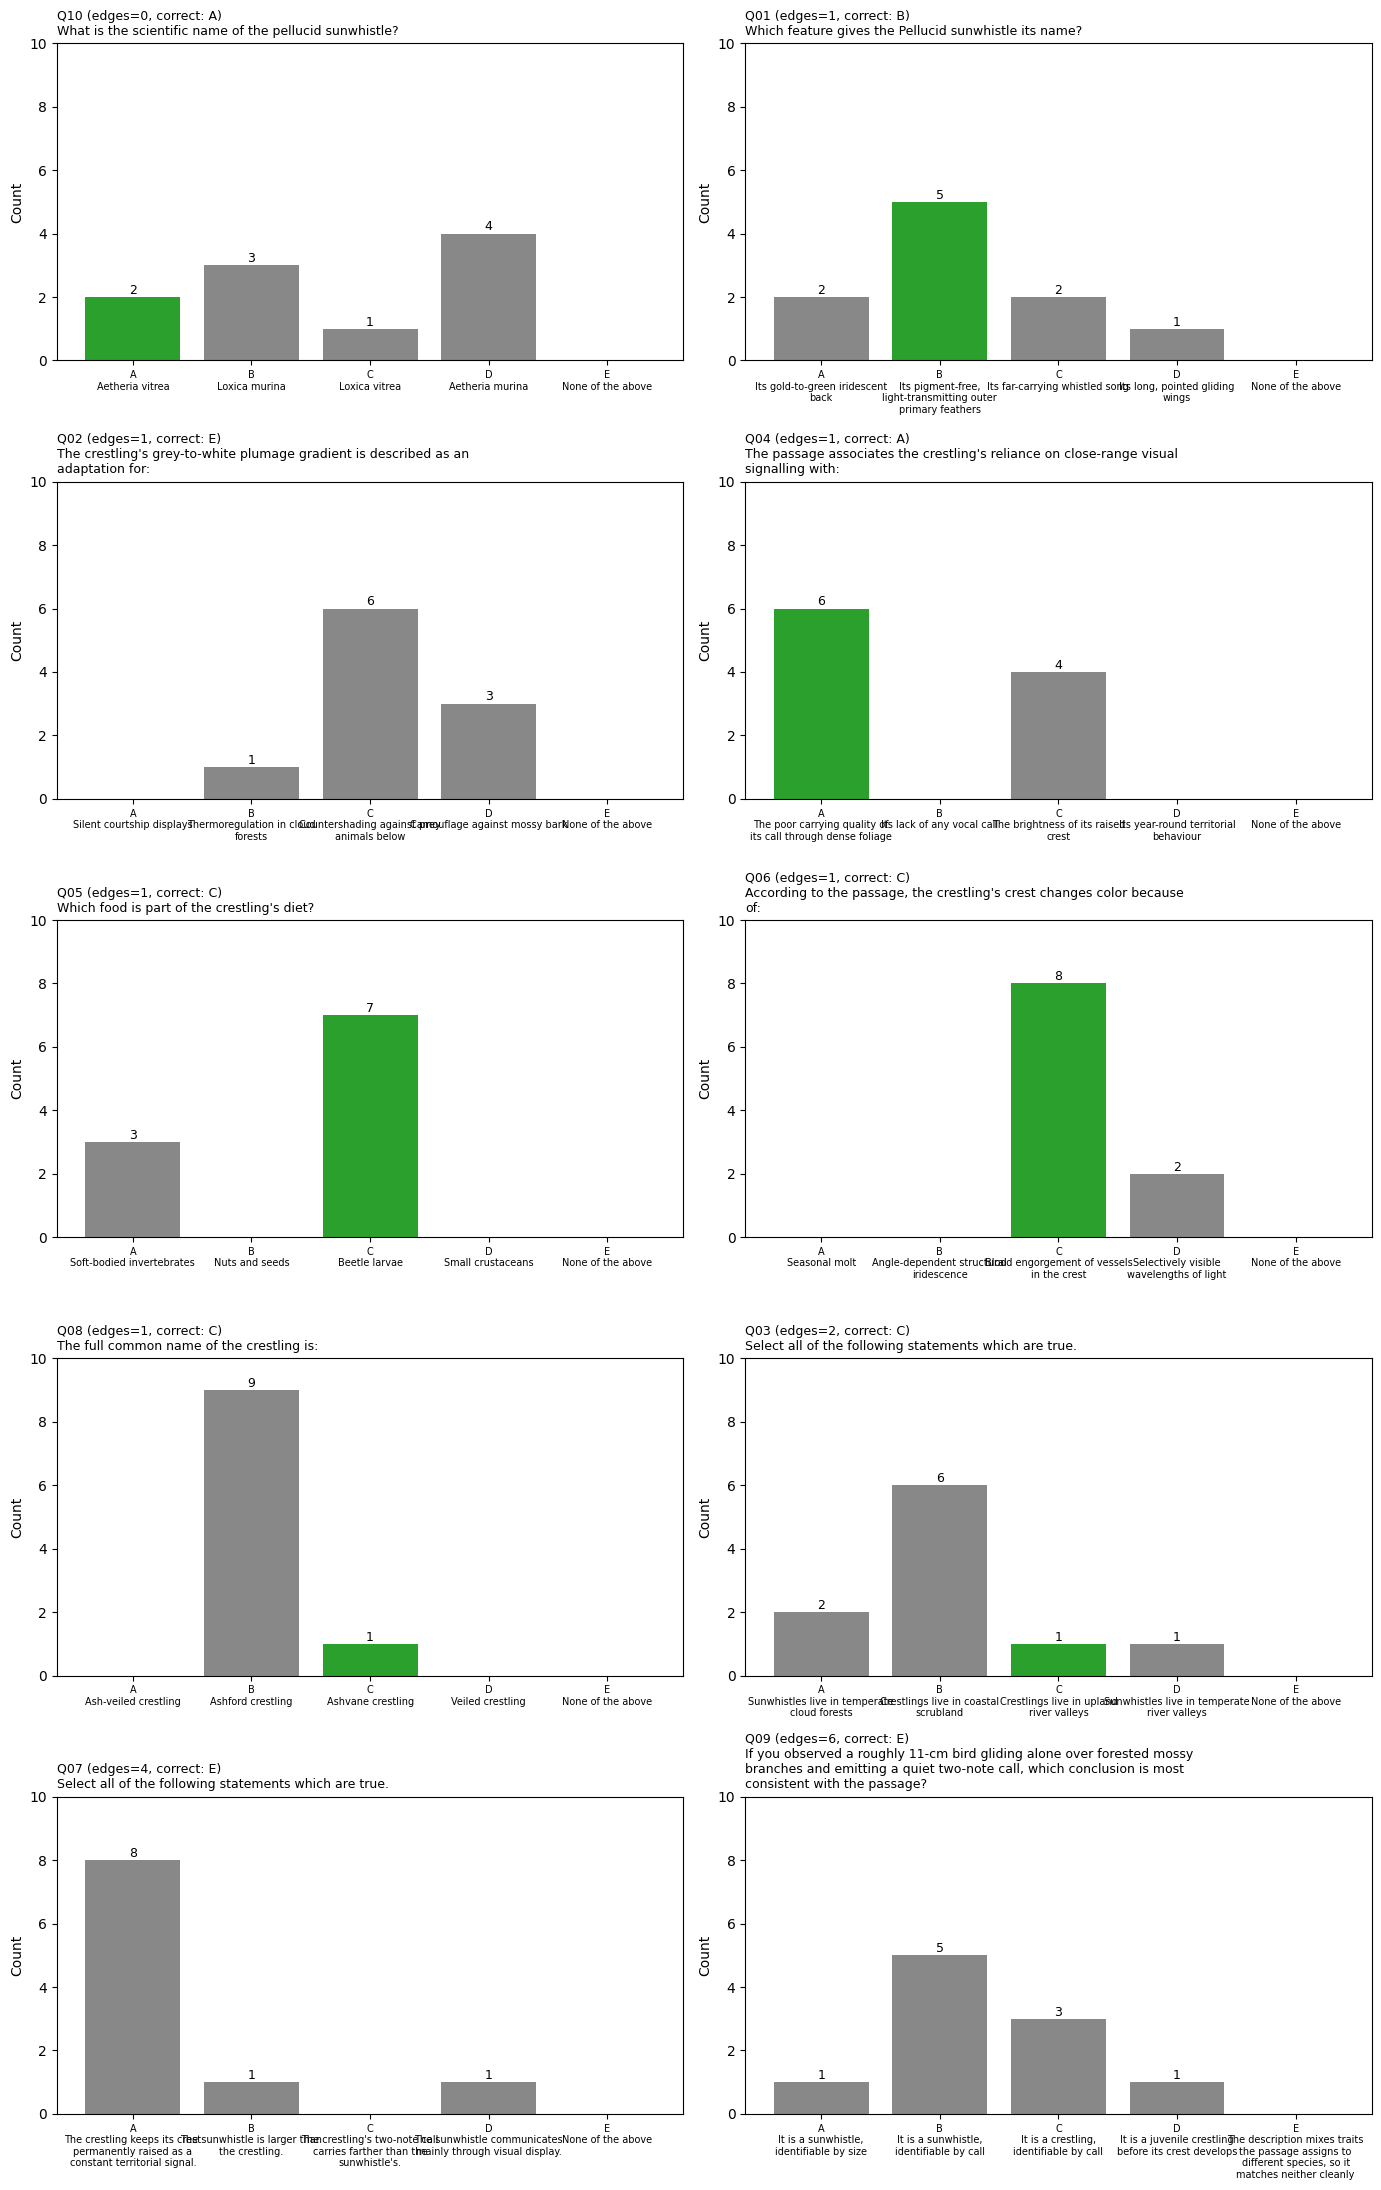

In [4]:
fig, axes = plt.subplots(5, 2, figsize=(14, 22))
axes = axes.flatten()
n_total = len(data_rows)

for ax, qid in zip(axes, SORTED_QIDS):
    counts, correct = tally(qid)
    q = by_id[qid]
    e = edges(qid)
    vals = [counts[L] for L in LETTERS]
    colors = ['#2ca02c' if L == correct else '#888' for L in LETTERS]
    labels = [f'{L}\n{wrap(q["options"][L], 30)}' for L in LETTERS]
    bars = ax.bar(labels, vals, color=colors)
    ax.set_ylim(0, n_total)
    ax.set_ylabel('Count')
    ax.set_title(f'{qid} (edges={e}, correct: {correct})\n{wrap(q["question"], 70)}', fontsize=9, loc='left')
    ax.tick_params(axis='x', labelsize=7)
    for b, v in zip(bars, vals):
        if v:
            ax.text(b.get_x() + b.get_width()/2, v + 0.1, str(v), ha='center', fontsize=9)

plt.tight_layout()
fig.savefig(f'answer_distributions_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

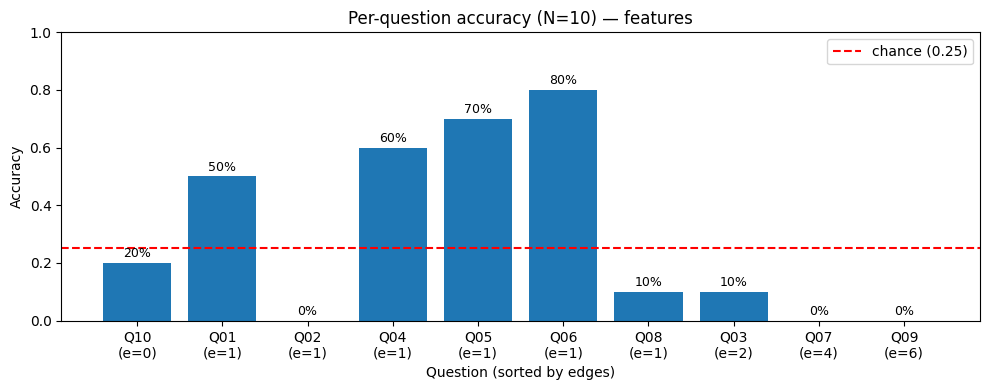

In [5]:
accs = []
for qid in SORTED_QIDS:
    counts, correct = tally(qid)
    n = sum(counts.values())
    accs.append((qid, counts[correct] / n if n else 0, edges(qid)))

fig, ax = plt.subplots(figsize=(10, 4))
labels = [f'{q}\n(e={e})' for q, _, e in accs]
ax.bar(labels, [a[1] for a in accs], color='#1f77b4')
ax.axhline(0.25, color='red', ls='--', label='chance (0.25)')
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_xlabel('Question (sorted by edges)')
ax.set_title(f'Per-question accuracy (N={n_total}) — {TAG}')
ax.legend()
for i, (qid, a, e) in enumerate(accs):
    ax.text(i, a + 0.02, f'{a:.0%}', ha='center', fontsize=9)
plt.tight_layout()
fig.savefig(f'per_question_accuracy_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
import numpy as np

def resp_letter(r, qid):
    opts = by_id[qid]['options']
    text_to_letter = {v.strip(): k for k, v in opts.items()}
    val = r.get(qid, '').strip()
    if val in LETTERS:
        return val
    if val in text_to_letter:
        return text_to_letter[val]
    return next((k for k, v in opts.items() if v.strip().split() == val.split()), None)

# Per-person correctness matrix (rows=people, cols=questions in SORTED_QIDS order).
M = np.zeros((len(data_rows), len(SORTED_QIDS)), dtype=int)
for i, r in enumerate(data_rows):
    for j, qid in enumerate(SORTED_QIDS):
        letter = resp_letter(r, qid)
        M[i, j] = 1 if letter == by_id[qid]['answer'] else 0

person_acc = M.mean(axis=1)
# Sort people by accuracy descending (IRT convention: best on top).
order = np.argsort(-person_acc)
M_sorted = M[order]
person_acc_sorted = person_acc[order]
pids = [data_rows[i].get('PROLIFIC_PID', f'R{i}')[:8] or f'R{i}' for i in order]

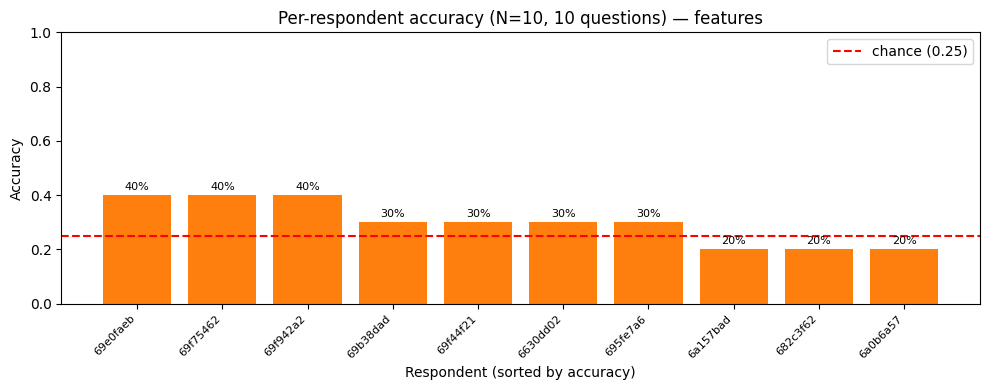

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(person_acc_sorted)), person_acc_sorted, color='#ff7f0e')
ax.axhline(0.25, color='red', ls='--', label='chance (0.25)')
ax.set_xticks(range(len(pids)))
ax.set_xticklabels(pids, rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_xlabel('Respondent (sorted by accuracy)')
ax.set_title(f'Per-respondent accuracy (N={len(pids)}, {len(SORTED_QIDS)} questions) — {TAG}')
for i, a in enumerate(person_acc_sorted):
    ax.text(i, a + 0.02, f'{a:.0%}', ha='center', fontsize=8)
ax.legend()
plt.tight_layout()
fig.savefig(f'per_respondent_accuracy_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

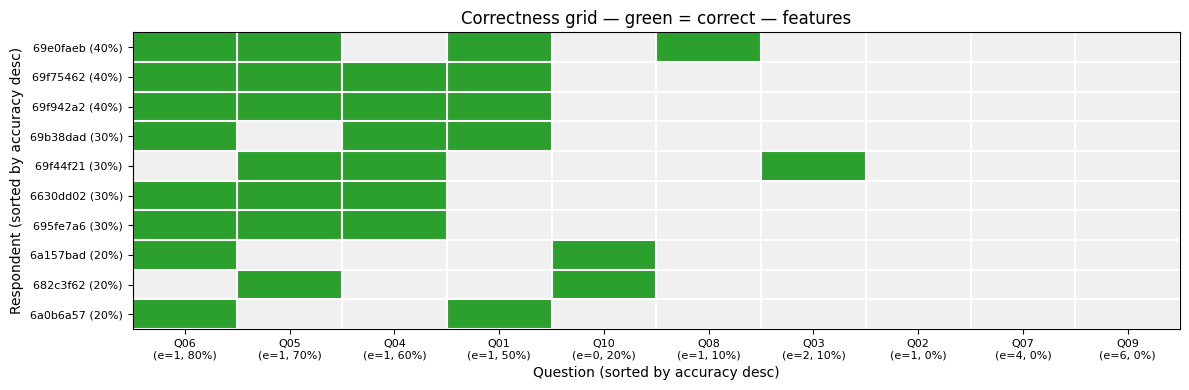

In [8]:
from matplotlib.colors import ListedColormap

q_acc = M_sorted.mean(axis=0)
col_order = np.argsort(-q_acc)
M_grid = M_sorted[:, col_order]
grid_qids = [SORTED_QIDS[j] for j in col_order]
grid_q_acc = q_acc[col_order]

fig, ax = plt.subplots(figsize=(12, max(4, 0.4 * len(pids))))
cmap = ListedColormap(['#f0f0f0', '#2ca02c'])
ax.imshow(M_grid, aspect='auto', cmap=cmap, vmin=0, vmax=1)

xtick_labels = [f'{q}\n(e={edges(q)}, {a:.0%})' for q, a in zip(grid_qids, grid_q_acc)]
ax.set_xticks(range(len(grid_qids)))
ax.set_xticklabels(xtick_labels, fontsize=8)
ax.set_yticks(range(len(pids)))
ax.set_yticklabels([f'{p} ({a:.0%})' for p, a in zip(pids, person_acc_sorted)], fontsize=8)
ax.set_xlabel('Question (sorted by accuracy desc)')
ax.set_ylabel('Respondent (sorted by accuracy desc)')
ax.set_title(f'Correctness grid — green = correct — {TAG}')

ax.set_xticks(np.arange(-0.5, len(grid_qids), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(pids), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=1.5)
ax.tick_params(which='minor', length=0)

plt.tight_layout()
fig.savefig(f'correctness_grid_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show()